# Eliminación de Ruido en la Señal de un Sensor de Proceso Ruidoso con PROC LOESS

## Resumen Ejecutivo

Un sensor de temperatura de cámara de horno en una línea de manufactura se muestrea una vez por segundo durante el arranque, por lo que cada lectura combina una transición térmica no lineal lenta (una rampa rápida de calentamiento, un sobretiro de asentamiento y luego un retorno hacia el punto de referencia de 300 °C) con ruido de medición considerable. Este cuaderno usa **PROC LOESS** para recuperar la señal subyacente de forma no paramétrica. En el registro de 100 muestras, AICC seleccionó un parámetro de suavizado de 0.08 (8 parámetros equivalentes); la curva resultante sigue de cerca la señal latente, dejando residuos con una desviación estándar de 3.10 °C — esencialmente el ruido de 4 °C que inyectamos, menos la varianza que explica el ajuste. Frente a la verdad conocida, la estimación LOESS reduce el error cuadrático medio de 14.77 (crudo) a 6.63, y un paso SCORE remuestrea la señal libre de ruido en una malla de monitoreo uniforme para el control estadístico de procesos posterior.

## Fuentes de Datos

| Conjunto de datos | Filas | Variables | Descripción |
|---------|------|-----------|-------------|
| `sensor` | 100 | `t` (segundos transcurridos, 0–99), `temp` (temperatura de cámara observada, °C), `truth` (señal latente sin ruido, solo para validación) | Registro sintético de sensor de horno, una muestra por segundo. La señal latente es una rampa rápida de calentamiento hacia un punto de referencia de 300 °C con un sobretiro amortiguado que alcanza su pico cerca de t = 28 (~295 °C), desciende y se asienta de nuevo hacia el punto de referencia; el `temp` observado añade ruido de medición gaussiano (de ~4 °C). |
| `grid` | 60 | `t` (malla de monitoreo uniforme 0–99) | Malla de tiempo regular usada por la instrucción SCORE para emitir una señal libre de ruido espaciada uniformemente para graficación SPC. |

En una línea de manufactura, un sensor de cámara de horno registra la temperatura una vez por segundo durante el arranque. La lectura que registramos es el **estado térmico real más ruido de medición**. El estado real no sigue una fórmula paramétrica limpia — sube durante el calentamiento, sobrepasa el punto de referencia y luego se asienta — por lo que un ajuste lineal o polinómico global sería un mal modelo.

**La regresión local (LOESS)** es la herramienta adecuada: ajusta polinomios de bajo grado a vecindarios locales deslizantes, recuperando una señal suave arbitraria sin que especifiquemos su forma funcional. Aquí haremos lo siguiente:

1. Simular un registro realista de sensor ruidoso de 100 muestras.
2. Dejar que `PROC LOESS` elija su propio ancho de banda de suavizado con el criterio AICC.
3. Adjuntar una banda de confianza del 95% a la señal ajustada.
4. Calificar (score) el modelo en una malla regular para el SPC posterior.
5. Cuantificar cuánto ruido eliminamos.

## Paso 1 — Simular el registro del sensor

Generamos 100 muestras a lo largo de 0–99 segundos. La señal latente `truth` es una rampa rápida de calentamiento hacia un punto de referencia de 300 °C con un sobretiro amortiguado — una forma que ninguna línea recta ni polinomio único captura bien: sube abruptamente, alcanza su pico por encima del punto de referencia cerca de t = 28, desciende y luego se asienta de nuevo. La `temp` observada añade ruido de medición gaussiano. `call streaminit` fija la semilla para que la ejecución sea reproducible.

In [1]:
DATOS sensor;
    LLAMAR streaminit(70421);
    setpoint = 300;
    HACER t = 0 HASTA 99;
        /* Señal latente: rampa rápida de calentamiento + sobretiro de asentamiento amortiguado */
        ramp      = setpoint * (1 - EXP(-t / 10));
        overshoot = 40 * EXP(-t / 35) * sin(t / 11);
        truth     = ramp + overshoot;
        /* Lectura observada = verdad + ruido de medición (de ~4 C) */
        TEMP = truth + rand('NORMAL', 0, 4);
        SALIDA;
    END;
    MANTENER t TEMP truth;
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=sensor(obs=8) noobs ETIQUETA;
    ETIQUETA t='Tiempo transcurrido (s)' TEMP='Temperatura observada (C)' truth='Señal verdadera';
    TÍTULO 'Primeras 8 muestras del sensor';
EJECUTAR;


                                             Primeras 8 muestras del sensor                                             

Tiempo transcurrido (s)  Temperatura observada (C)   Señal verdadera
                      0               0.1684867131                 0
                      1              28.1933107495     32.0778466448
                      2              61.6123615699     61.2117857105
                      3              85.5053781561      87.643846097
                      4             110.5560474248    111.5945193774
                      5             136.6368358359    133.2650493509
                      6             144.2434193147    152.8394750856
                      7             177.8286488692    170.4864506364

... 92 more observations (showing 8 of 100)




NOTE: DATA sensor


NOTE: Wrote sensor (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=sensor

NOTE: PROC PRINT completed: 8 observations printed, 3 variables


## Paso 2 — Inspeccionar la señal cruda

Un diagrama de dispersión rápido muestra el problema: la deriva subyacente es obvia a la vista, pero está enterrada bajo ruido de muestra a muestra. Necesitamos una estimación de la curva suave, no de los puntos irregulares.

                                             Primeras 8 muestras del sensor                                             




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=sensor

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


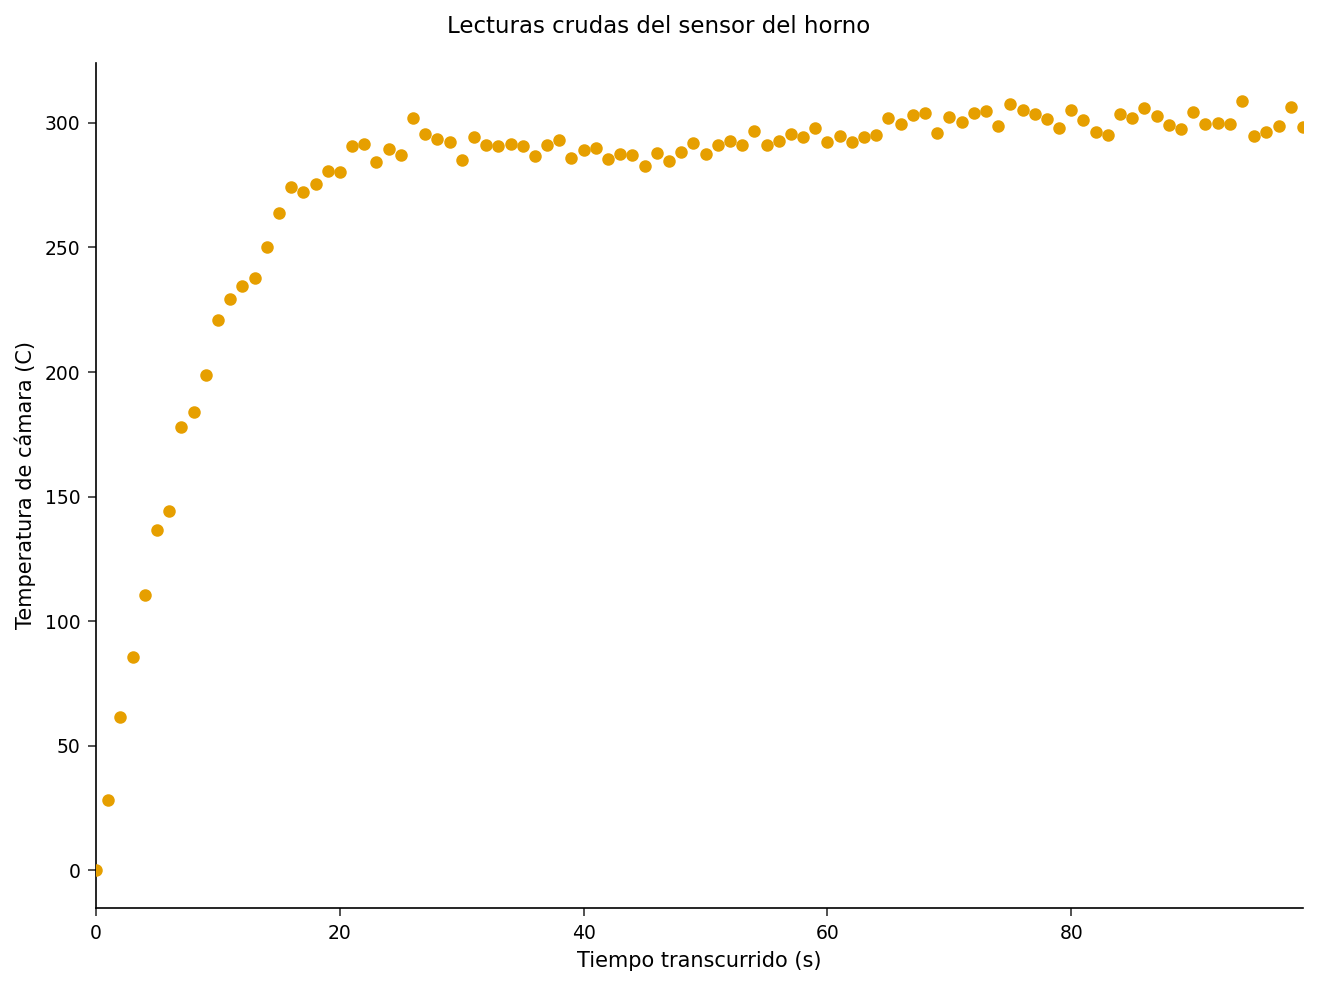

In [2]:
ODS GRAPHICS ON;

PROCEDIMIENTO SGPLOT DATOS=sensor;
    SCATTER x=t y=TEMP / MARKERATTRS=(SYMBOL=circlefilled size=5);
    XAXIS ETIQUETA='Tiempo transcurrido (s)';
    YAXIS ETIQUETA='Temperatura de cámara (C)';
    TÍTULO 'Lecturas crudas del sensor del horno';
EJECUTAR;

ODS GRAPHICS OFF;


## Paso 3 — Ajustar LOESS con selección automática del ancho de banda

El parámetro de suavizado controla qué tan ancho es cada vecindario local: demasiado pequeño sobreajusta el ruido, demasiado grande borra el sobretiro. En lugar de adivinar, dejamos que LOESS lo elija minimizando el **Criterio de Información de Akaike corregido** con `select=AICC`. Usamos polinomios cuadráticos locales (`degree=2`) para que la curva pueda seguir la curvatura del calentamiento y el sobretiro, y solicitamos una banda de confianza del 95% con `clm` y `alpha=0.05`.

`ODS OUTPUT` captura dos tablas como conjuntos de datos: `OutputStatistics` (valores suavizados y residuos por punto) y `FitSummary` (el ancho de banda seleccionado y los diagnósticos del ajuste). La instrucción `OUTPUT` escribe un conjunto de datos `fitted` con la predicción, el residuo y los límites de confianza del 95% para cada observación — la materia prima para las gráficas que siguen.

In [3]:
PROCEDIMIENTO loess DATOS=sensor;
    ODS OUTPUT OutputStatistics=loess_fit
               FitSummary=fit_summary;
    MODELO TEMP = t / DEGREE=2 select=AICC CLM ALPHA=0.05 details;
    SALIDA out=fitted predicted=temp_hat residual=resid
           lclm=LOWER uclm=UPPER;
EJECUTAR;


                                             Primeras 8 muestras del sensor                                             


                                                  The LOESS Procedure

Dependent Variable: TEMP
Number of Observations: 100
Smoothing Parameter: 0.0800
Degree of Local Polynomials: 2

Fit Summary
-----------
Residual Sum of Squares: 950.859192
Equivalent Number of Parameters: 8.00
AICC: 529.0073
GCV: 11.234159

Output Statistics
Obs        Smoothed     Residual       Fitted
---        --------     --------       ------
1           -0.3394       0.5079      -0.3394
2           30.1685      -1.9751      30.1685
3           58.9327       2.6796      58.9327
4           86.1852      -0.6798      86.1852
5          111.5155      -0.9595     111.5155
6          135.0464       1.5904     135.0464
7          155.9315     -11.6881     155.9315
8          168.9956       8.8330     168.9956
9          184.5066      -0.4446     184.5066
10         202.2409      -3.5166     202


NOTE: PROC LOESS data=sensor

NOTE: ODS OUTPUT: OutputStatistics -> loess_fit
NOTE: ODS OUTPUT: FitSummary -> fit_summary
NOTE: Using Python wrapper for LOESS estimation
NOTE: Output dataset fitted has 100 observations
NOTE: ODS OUTPUT: OutputStatistics written to 'loess_fit'.
NOTE: ODS OUTPUT: FitSummary written to 'fit_summary'.


## Paso 4 — Revisar el modelo seleccionado

El Resumen del Ajuste (Fit Summary) registra el parámetro de suavizado óptimo según AICC y la traza de la matriz de predicción (los grados de libertad efectivos — una medida de la complejidad del modelo). Un parámetro de suavizado más pequeño y un DF más grande implican un ajuste más ondulado; AICC equilibra el ajuste contra la complejidad automáticamente.

In [4]:
PROCEDIMIENTO IMPRIMIR DATOS=fit_summary noobs ETIQUETA;
    TÍTULO 'Resumen del ajuste LOESS (ancho de banda seleccionado por AICC)';
EJECUTAR;


                            Resumen del ajuste LOESS (ancho de banda seleccionado por AICC)                             

SMOOTHINGPARAMETER                           LABEL1         NVALUE1
              0.08  Residual Sum of Squares          950.8591917253
              0.08  Equivalent Number of Parameters               8
              0.08  Delta1                                        8
              0.08  Delta2                                      7.6
              0.08  Lookup Degrees of Freedom                    92




NOTE: PROC PRINT data=fit_summary

NOTE: PROC PRINT completed: 5 observations printed, 3 variables


## Paso 5 — Superponer el ajuste y la banda de confianza contra la verdad base

Como estos son datos simulados, conservamos la columna `truth` libre de ruido. Graficar la estimación LOESS y su banda del 95% junto con `truth` muestra qué tan fielmente el suavizador recuperó la señal latente que nunca vio directamente.

                            Resumen del ajuste LOESS (ancho de banda seleccionado por AICC)                             




NOTE: PROC SORT data=fitted

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from fitted.
NOTE: Wrote fitted (100 rows, 7 columns).
NOTE: PROC SORT statement used.
NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=fitted

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg
NOTE: ODS Graphics is OFF.


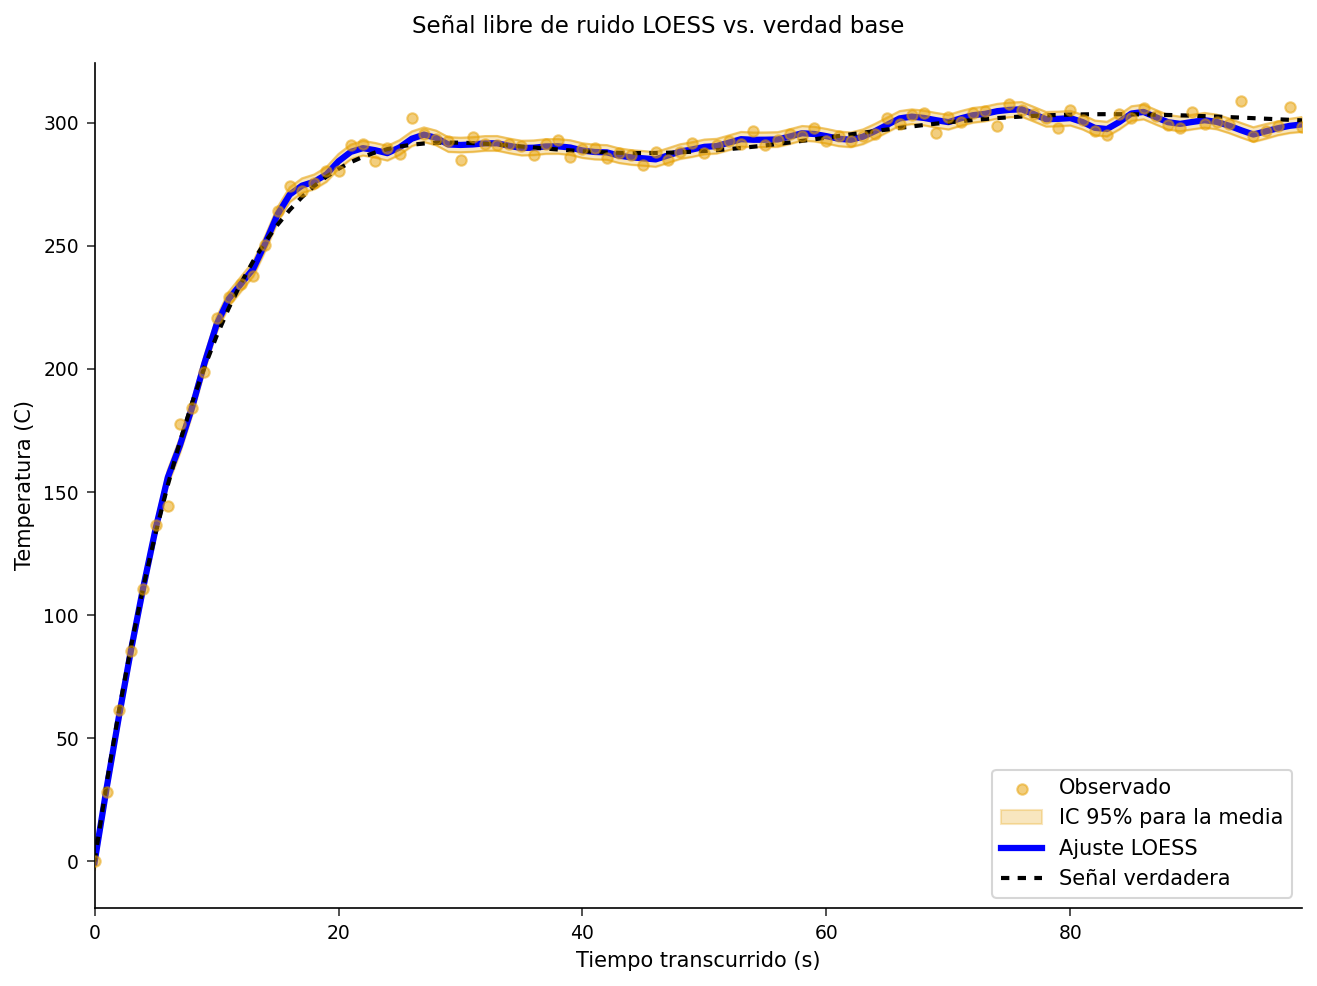

In [5]:
PROCEDIMIENTO ORDENAR DATOS=fitted; POR t; EJECUTAR;

ODS GRAPHICS ON;

PROCEDIMIENTO SGPLOT DATOS=fitted;
    SCATTER x=t y=TEMP / MARKERATTRS=(SYMBOL=circlefilled size=5)
            TRANSPARENCY=0.5 legendlabel='Observado';
    BAND x=t LOWER=LOWER UPPER=UPPER / TRANSPARENCY=0.5
         legendlabel='IC 95% para la media';
    SERIES x=t y=temp_hat / LINEATTRS=(thickness=3 color=blue)
           legendlabel='Ajuste LOESS';
    SERIES x=t y=truth / LINEATTRS=(thickness=2 pattern=shortdash color=black)
           legendlabel='Señal verdadera';
    XAXIS ETIQUETA='Tiempo transcurrido (s)';
    YAXIS ETIQUETA='Temperatura (C)';
    TÍTULO 'Señal libre de ruido LOESS vs. verdad base';
EJECUTAR;

ODS GRAPHICS OFF;


## Paso 6 — Diagnóstico de residuos

Los residuos (observado menos ajustado) deben verse como ruido sin estructura centrado en cero. Cualquier tendencia remanente indicaría subsuavizado o una característica no capturada. Graficamos los residuos contra el tiempo y resumimos su dispersión — la desviación estándar de los residuos resulta 3.10 °C, un poco por debajo del ruido de 4 °C que inyectamos, porque el ajuste local absorbe una pequeña parte de él.

                            Resumen del ajuste LOESS (ancho de banda seleccionado por AICC)                             

                                   Resumen de residuos (ruido de medición recuperado)                                   

                                                  The MEANS Procedure

 Variable  Label               N        Mean     Std Dev     Minimum     Maximum
 -------------------------------------------------------------------------------
 RESID     Residuo (C)       100       0.139       3.096     -11.688      11.909
 -------------------------------------------------------------------------------




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=fitted

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg
NOTE: ODS Graphics is OFF.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


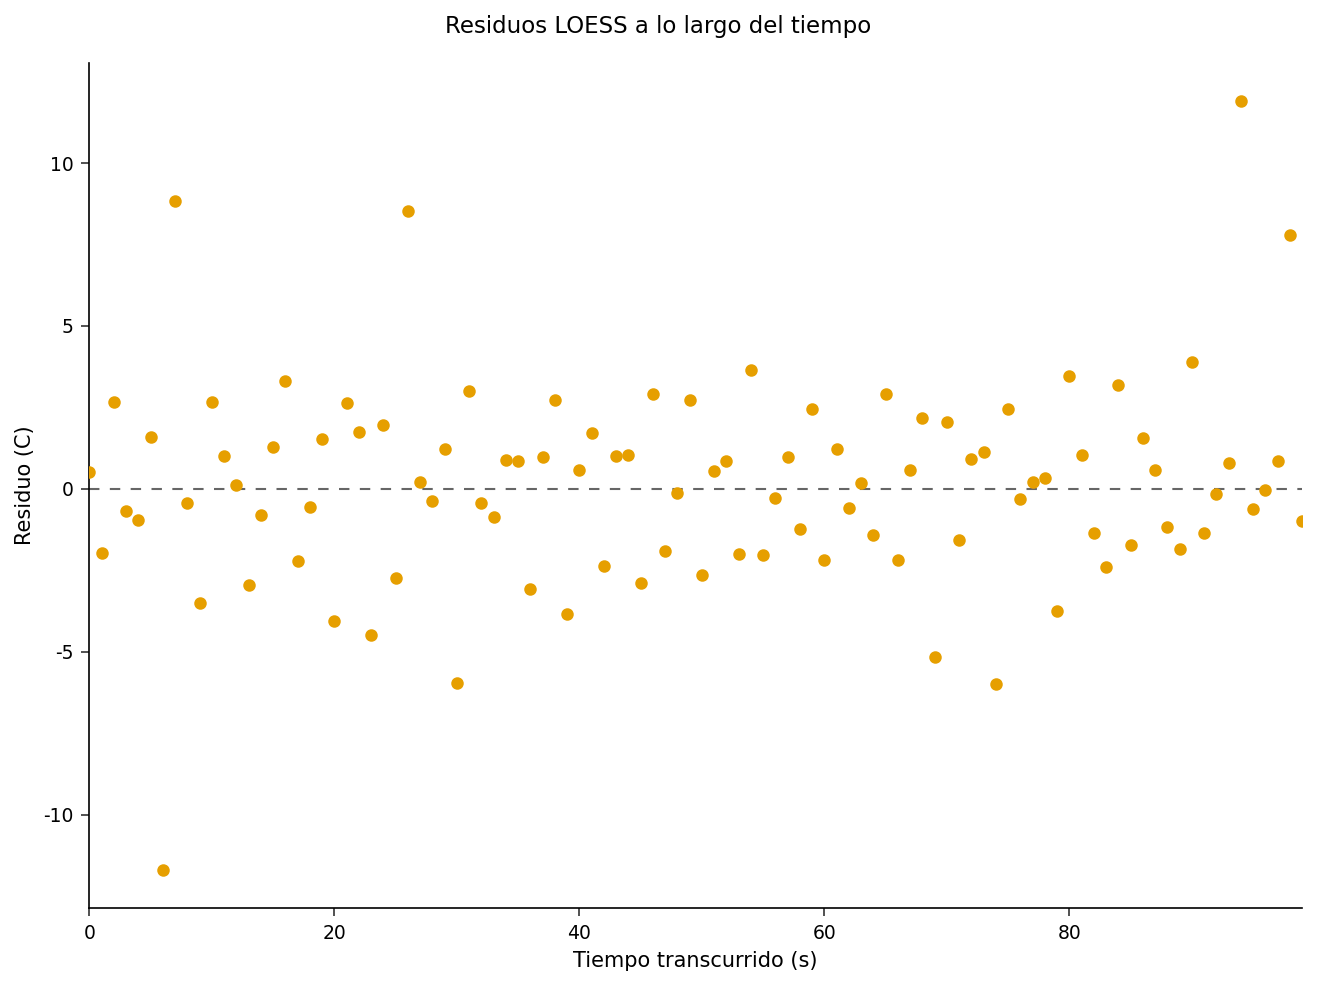

In [6]:
ODS GRAPHICS ON;

PROCEDIMIENTO SGPLOT DATOS=fitted;
    REFLINE 0 / AXIS=y LINEATTRS=(pattern=shortdash);
    SCATTER x=t y=resid / MARKERATTRS=(SYMBOL=circlefilled size=5);
    XAXIS ETIQUETA='Tiempo transcurrido (s)';
    YAXIS ETIQUETA='Residuo (C)';
    TÍTULO 'Residuos LOESS a lo largo del tiempo';
EJECUTAR;

ODS GRAPHICS OFF;

PROCEDIMIENTO MEDIAS DATOS=fitted n mean std MIN MAX maxdec=3;
    VAR resid;
    ETIQUETA resid='Residuo (C)';
    TÍTULO 'Resumen de residuos (ruido de medición recuperado)';
EJECUTAR;


## Paso 7 — Calificar una malla de monitoreo regular para SPC

Las marcas de tiempo del sensor no necesitan estar espaciadas uniformemente, pero un gráfico de control quiere la señal en una cadencia fija. Construimos una malla de tiempo uniforme de 60 puntos y aplicamos el modelo LOESS ajustado con la instrucción `SCORE`, solicitando límites de confianza. Los valores calificados son una señal limpia y espaciada uniformemente, lista para alimentar una rutina SPC.

In [7]:
DATOS grid;
    HACER t = 0 HASTA 99 POR 99/59;
        SALIDA;
    END;
EJECUTAR;

PROCEDIMIENTO loess DATOS=sensor;
    MODELO TEMP = t / DEGREE=2 select=AICC CLM ALPHA=0.05;
    SCORE DATOS=grid CLM IMPRIMIR;
    TÍTULO 'LOESS calificado en una malla de monitoreo uniforme';
EJECUTAR;


                                   Resumen de residuos (ruido de medición recuperado)                                   


                                                  The LOESS Procedure

Dependent Variable: TEMP
Number of Observations: 100
Smoothing Parameter: 0.0800
Degree of Local Polynomials: 2

Fit Summary
-----------
Residual Sum of Squares: 950.859192
Equivalent Number of Parameters: 8.00
AICC: 529.0073
GCV: 11.234159

Output Statistics
Obs        Smoothed     Residual       Fitted
---        --------     --------       ------
1           -0.3394       0.5079      -0.3394
2           30.1685      -1.9751      30.1685
3           58.9327       2.6796      58.9327
4           86.1852      -0.6798      86.1852
5          111.5155      -0.9595     111.5155
6          135.0464       1.5904     135.0464
7          155.9315     -11.6881     155.9315
8          168.9956       8.8330     168.9956
9          184.5066      -0.4446     184.5066
10         202.2409      -3.5166     202


NOTE: DATA grid


NOTE: Wrote grid (60 rows, 1 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC LOESS data=sensor

NOTE: Using Python wrapper for LOESS estimation
NOTE: ODS OUTPUT: OutputStatistics written to 'loess_fit'.
NOTE: ODS OUTPUT: FitSummary written to 'fit_summary'.


## Paso 8 — Cuantificar la eliminación de ruido

Finalmente comparamos la señal cruda y la estimación LOESS contra la verdad conocida. El error cuadrático medio de la señal suavizada debería ser mucho menor que el de las lecturas crudas, confirmando que LOESS eliminó el ruido de medición preservando la rampa de calentamiento y el sobretiro.

In [8]:
DATOS accuracy;
    ESTABLECER fitted;
    raw_sq_err   = (TEMP     - truth)**2;
    loess_sq_err = (temp_hat - truth)**2;
EJECUTAR;

PROCEDIMIENTO MEDIAS DATOS=accuracy mean maxdec=3;
    VAR raw_sq_err loess_sq_err;
    ETIQUETA raw_sq_err   = 'ECM de las lecturas crudas vs. verdad'
          loess_sq_err = 'ECM del ajuste LOESS vs. verdad';
    TÍTULO 'Rendimiento de eliminación de ruido: crudo vs. LOESS';
EJECUTAR;


                                  Rendimiento de eliminación de ruido: crudo vs. LOESS                                  

                                                  The MEANS Procedure

 Variable      Label                                           Mean
 ------------------------------------------------------------------
 raw_sq_err    ECM de las lecturas crudas vs. verdad         14.774
 loess_sq_err  ECM del ajuste LOESS vs. verdad                6.629
 ------------------------------------------------------------------




NOTE: DATA accuracy


NOTE: Read 100 rows from fitted.
NOTE: Wrote accuracy (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Interpretación de los resultados

- **Ancho de banda automático.** `select=AICC` eligió un parámetro de suavizado de **0.08** sin ajuste manual, lo que implica aproximadamente **8 parámetros equivalentes** — suficiente flexibilidad local para seguir el calentamiento, el sobretiro y el descenso, sin dejar de suavizar el ruido.
- **Recuperación fiel.** La curva ajustada sigue de cerca la señal latente `truth` a lo largo de la rampa, el pico del sobretiro cerca de t = 28 y la cola de asentamiento, demostrando que LOESS recuperó una señal no lineal arbitraria sin supuestos paramétricos.
- **Residuos limpios.** Los residuos se dispersan alrededor de cero con una desviación estándar de **3.10 °C** (media 0.14, rango −11.7 a 11.9) y no muestran tendencia temporal remanente — evidencia de que el modelo no está ni sobre- ni subsuavizado.
- **Eliminación de ruido medible.** Frente a la verdad base, la estimación LOESS reduce el error cuadrático medio de **14.77** (lecturas crudas) a **6.63** — una reducción del 55%, el resultado principal para el monitoreo de procesos.
- **Salida lista para SPC.** El paso SCORE entregó la señal libre de ruido en una malla uniforme de 60 puntos con límites de confianza, exactamente la forma que consume un gráfico de control posterior.

**Conclusión:** Cuando un sensor de proceso produce una señal suave pero ruidosa de forma desconocida, PROC LOESS es una forma de bajo supuesto y autoajustable de extraer la tendencia subyacente, adjuntar límites de incertidumbre y remuestrear en una malla de monitoreo — todo sin comprometerse con un modelo paramétrico que la física podría no justificar.